In [15]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [16]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'static_tests': {'target': 1, 'reference': 1},
 'dynamic_tests': {'target': 1, 'reference': 1}}

In [17]:
TEST_NUM = OPTIONS['dynamic_tests'].get('target')
PATH     = f'files/test{TEST_NUM}'
print(PATH)

INFO = json.loads(open(f'{PATH}/info.json', 'r', encoding='utf-8').read())
INFO

files/test1


{'variable': 'roll', 'limits': [0, 1000000000.0]}

In [18]:
TARGET_VAR  = INFO.get('variable')
TEST_VAR    = OPTIONS.get('test')
TARGET_TIME = tuple(INFO.get('limits'))

# IMPORTANDO DADOS

In [19]:
df = pd.read_csv(f'{PATH}/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,ay,roll,wx,tmp,wy,time,yaw,az,ax,pitch,wz
0,-48355,2215,20030,30.9,-45196,0.000000,359897,995558,-36467,-2998,-32567
1,-49793,2214,-36181,31.1,-8820,0.101275,359896,997669,-37071,-2996,-20861
2,-54622,2213,17246,30.8,13682,0.201469,359897,997378,-38105,-2991,16146
3,-50103,2214,-17076,31.2,23667,0.309372,359895,998216,-40628,-2989,1537
4,-50561,2216,18635,31.1,35889,0.404137,359894,992794,-39318,-2987,-12174
...,...,...,...,...,...,...,...,...,...,...,...
3021,-64787,2303,9543,45.3,-22194,302.109516,3876,994035,-40850,-3761,16747
3022,-65502,2304,-26315,45.6,-13993,302.205482,3877,993291,-38711,-3763,27232
3023,-65278,2305,-14794,45.3,23408,302.312336,3875,996852,-41860,-3765,-2191
3024,-66383,2303,394,45.6,-19104,302.408922,3875,994714,-38432,-3761,11509


- Convertendo pra radianos

In [20]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,ay,roll,wx,tmp,wy,time,yaw,az,ax,pitch,wz
0,-0.474201,2.215,0.20030,30.9,-0.45196,0.000000,359.897,9.763089,-0.357619,-2.998,-0.32567
1,-0.488303,2.214,-0.36181,31.1,-0.08820,0.101275,359.896,9.783791,-0.363542,-2.996,-0.20861
2,-0.535659,2.213,0.17246,30.8,0.13682,0.201469,359.897,9.780937,-0.373682,-2.991,0.16146
3,-0.491343,2.214,-0.17076,31.2,0.23667,0.309372,359.895,9.789155,-0.398425,-2.989,0.01537
4,-0.495834,2.216,0.18635,31.1,0.35889,0.404137,359.894,9.735983,-0.385578,-2.987,-0.12174


- Formatando as colunas pra ficar igual a de referência

In [21]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,ay,roll,wx,tmp,wy,time,yaw,az,ax,pitch,wz
0,9.763089,-2.998,0.20030,30.9,0.32567,0.000000,359.897,-0.474201,-0.357619,-2.215,-0.45196
1,9.783791,-2.996,-0.36181,31.1,0.20861,0.101275,359.896,-0.488303,-0.363542,-2.214,-0.08820
2,9.780937,-2.991,0.17246,30.8,-0.16146,0.201469,359.897,-0.535659,-0.373682,-2.213,0.13682
3,9.789155,-2.989,-0.17076,31.2,-0.01537,0.309372,359.895,-0.491343,-0.398425,-2.214,0.23667
4,9.735983,-2.987,0.18635,31.1,0.12174,0.404137,359.894,-0.495834,-0.385578,-2.216,0.35889


# VISUALIZAÇÃO DE VARIÁVEIS

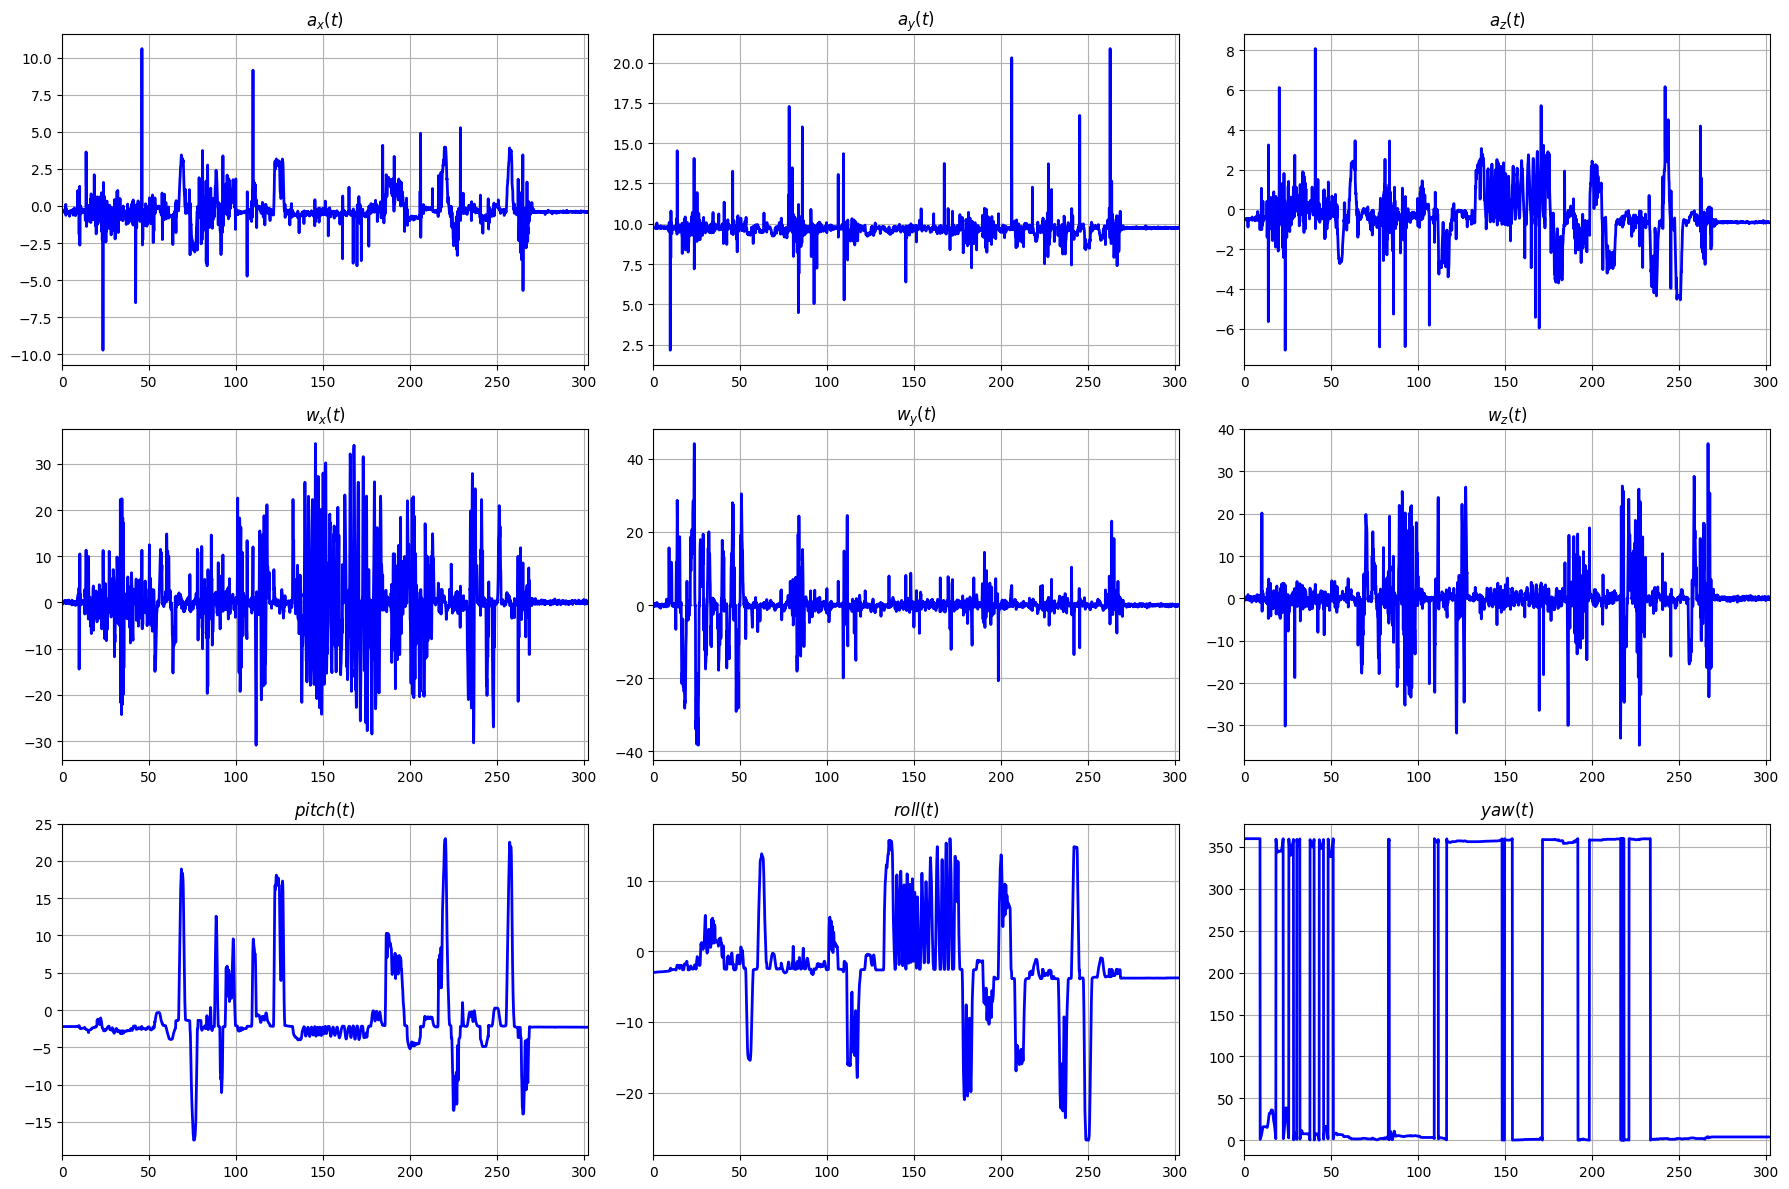

In [22]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals, color='blue', linewidth=2)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

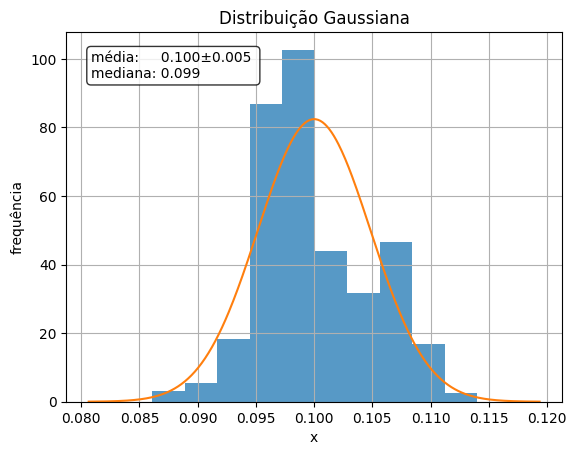

In [23]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [24]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,ay,roll,wx,tmp,wy,yaw,az,ax,pitch,wz
0,0.0,9.763089,-2.998,0.20030,30.9,0.32567,359.897,-0.474201,-0.357619,-2.215,-0.45196
1,0.1,9.763089,-2.998,0.20030,30.9,0.32567,359.897,-0.474201,-0.357619,-2.215,-0.45196
2,0.2,9.783791,-2.996,-0.36181,31.1,0.20861,359.896,-0.488303,-0.363542,-2.214,-0.08820
3,0.3,9.780937,-2.991,0.17246,30.8,-0.16146,359.897,-0.535659,-0.373682,-2.213,0.13682
4,0.4,9.789155,-2.989,-0.17076,31.2,-0.01537,359.895,-0.491343,-0.398425,-2.214,0.23667
...,...,...,...,...,...,...,...,...,...,...,...
3022,302.2,9.748153,-3.761,0.09543,45.3,-0.16747,3.876,-0.635343,-0.400602,-2.303,-0.22194
3023,302.3,9.740857,-3.763,-0.26315,45.6,-0.27232,3.877,-0.642355,-0.379625,-2.304,-0.13993
3024,302.4,9.775779,-3.765,-0.14794,45.3,0.02191,3.875,-0.640158,-0.410506,-2.305,0.23408
3025,302.5,9.754812,-3.761,0.00394,45.6,-0.11509,3.875,-0.650995,-0.376889,-2.303,-0.19104


# FILTRANDO POR VARIAVEL

In [25]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

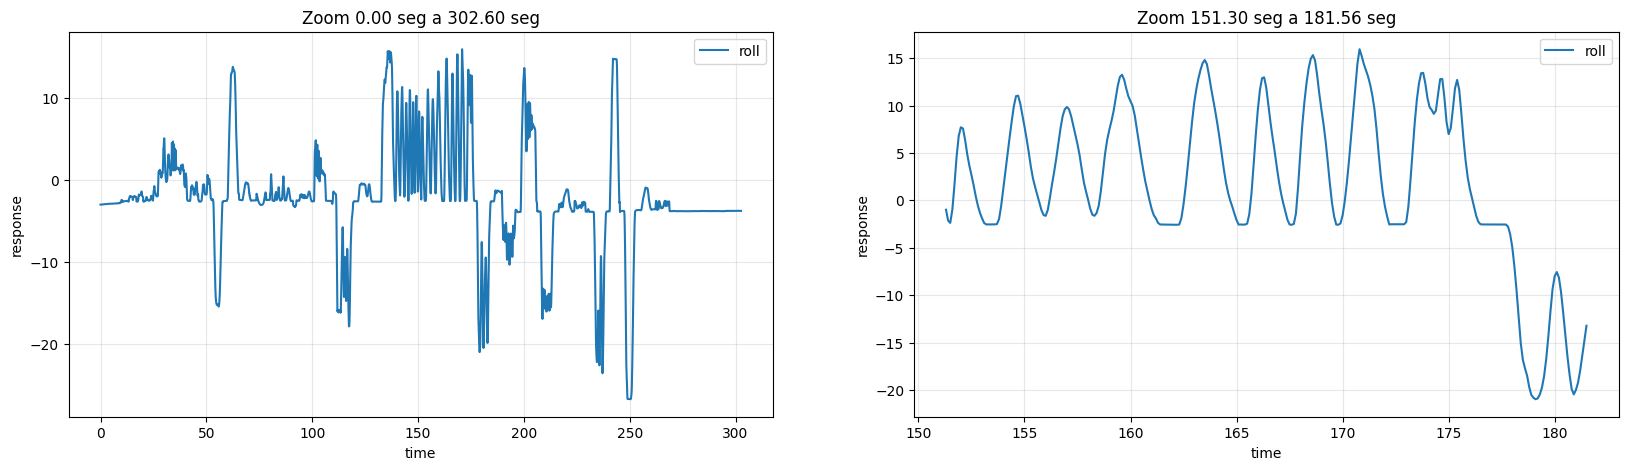

In [26]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [27]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col != 'time'})
df

,time,target_ay,target_roll,target_wx,target_tmp,target_wy,target_yaw,target_az,target_ax,target_pitch,target_wz
0,0.0,9.763089,-2.998,0.20030,30.9,0.32567,359.897,-0.474201,-0.357619,-2.215,-0.45196
1,0.1,9.763089,-2.998,0.20030,30.9,0.32567,359.897,-0.474201,-0.357619,-2.215,-0.45196
2,0.2,9.783791,-2.996,-0.36181,31.1,0.20861,359.896,-0.488303,-0.363542,-2.214,-0.08820
3,0.3,9.780937,-2.991,0.17246,30.8,-0.16146,359.897,-0.535659,-0.373682,-2.213,0.13682
4,0.4,9.789155,-2.989,-0.17076,31.2,-0.01537,359.895,-0.491343,-0.398425,-2.214,0.23667
...,...,...,...,...,...,...,...,...,...,...,...
3022,302.2,9.748153,-3.761,0.09543,45.3,-0.16747,3.876,-0.635343,-0.400602,-2.303,-0.22194
3023,302.3,9.740857,-3.763,-0.26315,45.6,-0.27232,3.877,-0.642355,-0.379625,-2.304,-0.13993
3024,302.4,9.775779,-3.765,-0.14794,45.3,0.02191,3.875,-0.640158,-0.410506,-2.305,0.23408
3025,302.5,9.754812,-3.761,0.00394,45.6,-0.11509,3.875,-0.650995,-0.376889,-2.303,-0.19104


In [28]:
os.makedirs(f'output', exist_ok=True)
INFO = {}

with open('output/info.json', 'w') as file:
    file.write(json.dumps(INFO, indent=4))

df.to_csv('output/data.csv', index=None)